In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import glob
import numpy as np

from torch.autograd import Variable
from torch.utils.data.dataset import TensorDataset
from torch.utils.data import DataLoader

In [2]:
import glob
import numpy as np

from IPython.display import HTML
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.animation import FuncAnimation

In [3]:
DATA_PATH = "D:/GitHub/BaseballPitch/modules/motion_prediction/output.txt"

file = glob.glob(f"{DATA_PATH}")
file

['D:/GitHub/BaseballPitch/modules/motion_prediction/output.txt']

In [4]:
# Load keypoints from output.txt and display shape
keypoints = np.loadtxt(file[0])
print('Keypoints shape:', keypoints.shape)

OUTPUT_LENGTH = keypoints.shape[0]
print('Output length:', OUTPUT_LENGTH)

Keypoints shape: (153, 56)
Output length: 153


<class_index> <x_center> <y_center> <width> <height> <px1> <py1> [<pconf1>] <px2> <py2> [<pconf2>] ... 

In [5]:
def groups_of_three(arr):
    """
    Splits arr into non-overlapping groups of three elements.
    If the length is not a multiple of 3, the last group will be shorter.
    """
    return [arr[i:i+3] for i in range(0, len(arr), 3)]

In [6]:
groups_of_three(keypoints[1][5:])

[array([0.366378, 0.452227, 0.991218]),
 array([0.364719 , 0.445655 , 0.0112103]),
 array([0.364307, 0.446118, 0.95474 ]),
 array([0.358159  , 0.447745  , 0.00161996]),
 array([0.357723, 0.451354, 0.998311]),
 array([0.369731, 0.487148, 0.999613]),
 array([0.33313 , 0.499501, 0.998992]),
 array([0.393704, 0.525201, 0.997823]),
 array([0.324854, 0.567628, 0.999208]),
 array([0.41495 , 0.555252, 0.997801]),
 array([0.326489, 0.626283, 0.998154]),
 array([0.359566, 0.587881, 0.999431]),
 array([0.337168, 0.595206, 0.998928]),
 array([0.384854, 0.655726, 0.999444]),
 array([0.357258, 0.656364, 0.999299]),
 array([0.422824, 0.716776, 0.998632]),
 array([0.343292, 0.745091, 0.997492])]

In [7]:
for i in range(17):
    kx, ky, kconf = groups_of_three(keypoints[i][5:])[i]  # Assuming the first 5 values are not keypoints
    print(kx, ky, kconf)

0.365704 0.450087 0.989136
0.364719 0.445655 0.0112103
0.365041 0.448644 0.970617
0.359876 0.452266 0.00187869
0.360511 0.457949 0.998385
0.373289 0.493502 0.999757
0.334451 0.505905 0.999353
0.407737 0.500628 0.998766
0.303005 0.543343 0.999363
0.437168 0.48473 0.998114
0.291189 0.588363 0.998381
0.360959 0.60451 0.999631
0.339321 0.609505 0.999259
0.377779 0.656752 0.999298
0.362446 0.678019 0.998899
0.371677 0.733855 0.998773
0.353735 0.737156 0.998287


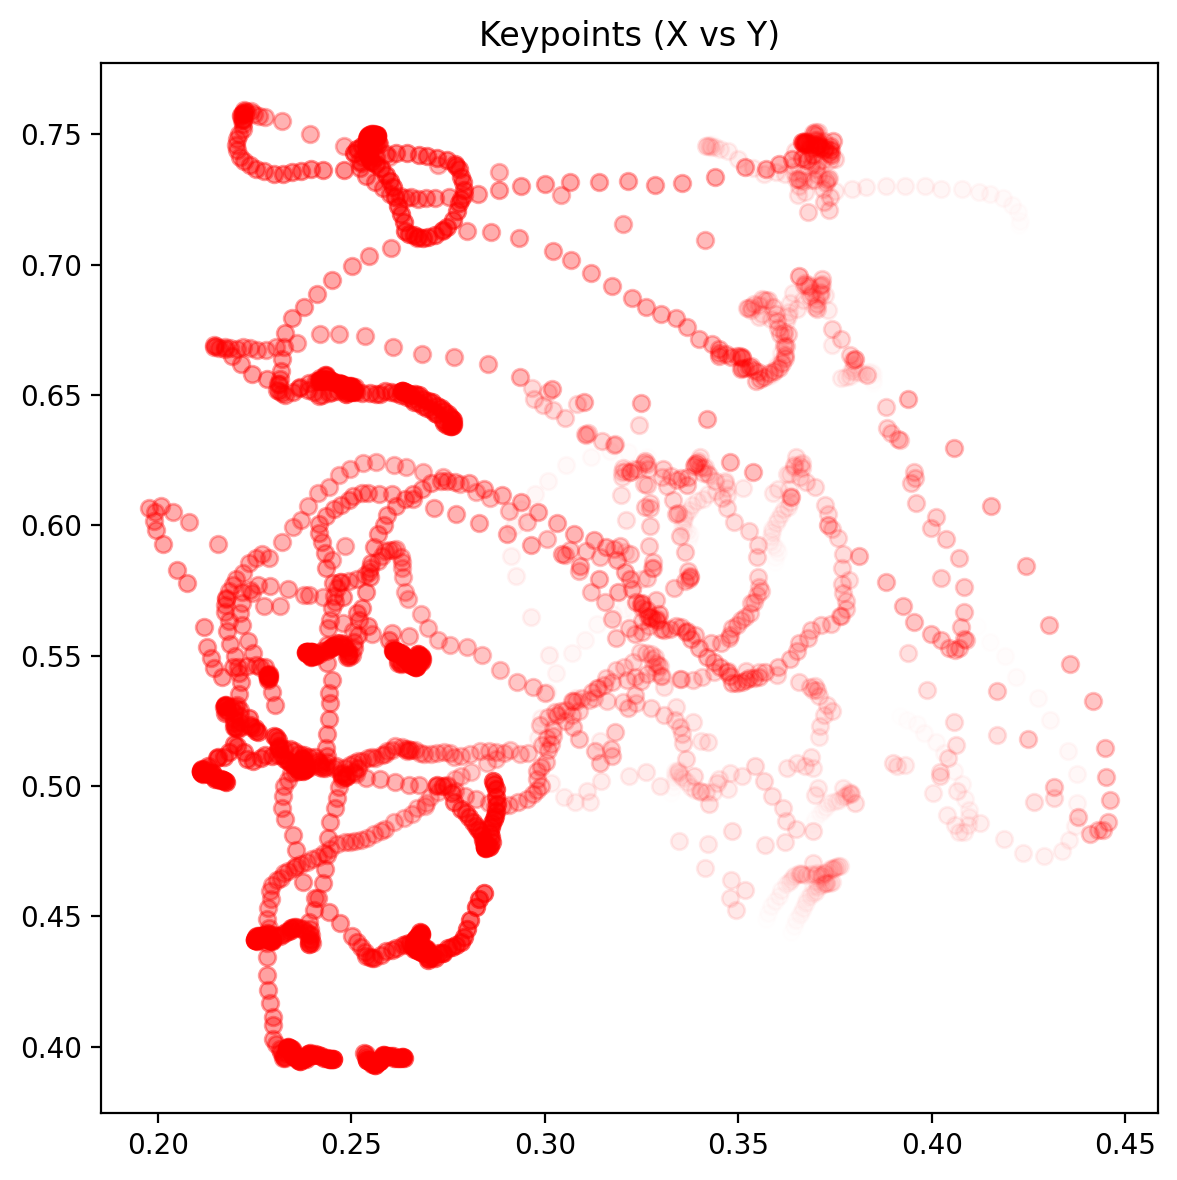

In [8]:
# XYZ coordinates subplot
fig, axs = plt.subplots(1, 1, figsize=(6, 6), facecolor='white', dpi=200)
alpha = 0

# XYZ coordinates for pos
for t in range(OUTPUT_LENGTH):
    alpha += 1.0 / 249  # Gradually decrease the transparency
    for i in range(17):
        kx, ky, kconf = groups_of_three(keypoints[t][5:])[i]  # Assuming the first 5 values are not keypoints

        if kconf > 0.5:
            axs.plot(kx, ky, 'ro', alpha = alpha)  # Plot keypoints as red dots
            axs.set_title('Keypoints (X vs Y)')

plt.tight_layout()
plt.show()

In [9]:
def plot_line(axs, pt1, pt2, **kwargs):
    """
    Plots a line between two points on the given matplotlib axis.
    pt1, pt2: (x, y) tuples or arrays
    axs: matplotlib axis object
    kwargs: additional arguments for axs.plot (e.g., color, linewidth)
    """
    x_values = [pt1[0], pt2[0]]
    y_values = [pt1[1], pt2[1]]
    axs.plot(x_values, y_values, **kwargs)

In [10]:
coco_connections = [
    # Head
    (0, 1), (0, 2), (1, 3), (2, 4),
    # Torso
    (5, 6), (5, 11), (6, 12), (11, 12),
    # Left Arm
    (5, 7), (7, 9),
    # Right Arm
    (6, 8), (8, 10),
    # Left Leg
    (11, 13), (13, 15),
    # Right Leg
    (12, 14), (14, 16)
]

In [11]:
edges = [([conn[0]], [conn[1]]) for conn in coco_connections]
print(edges[0])

([0], [1])


In [12]:
nodes = np.zeros([OUTPUT_LENGTH,17,2])
edges = np.zeros([OUTPUT_LENGTH,16,2,2])  # 12 edges, each with 2 points (start and end), each point has (x, y)

# XYZ coordinates for pos
for t in range(OUTPUT_LENGTH):
    for i in range(17):
        kx, ky, kconf = groups_of_three(keypoints[t][5:])[i]  # Assuming the first 5 values are not keypoints
        nodes[t][i] = ([kx, ky])
    edges[t] = [(nodes[t][conn[0]], nodes[t][conn[1]]) for conn in coco_connections]
    
print(edges[0][0])

[[0.365704 0.450087]
 [0.364059 0.443469]]


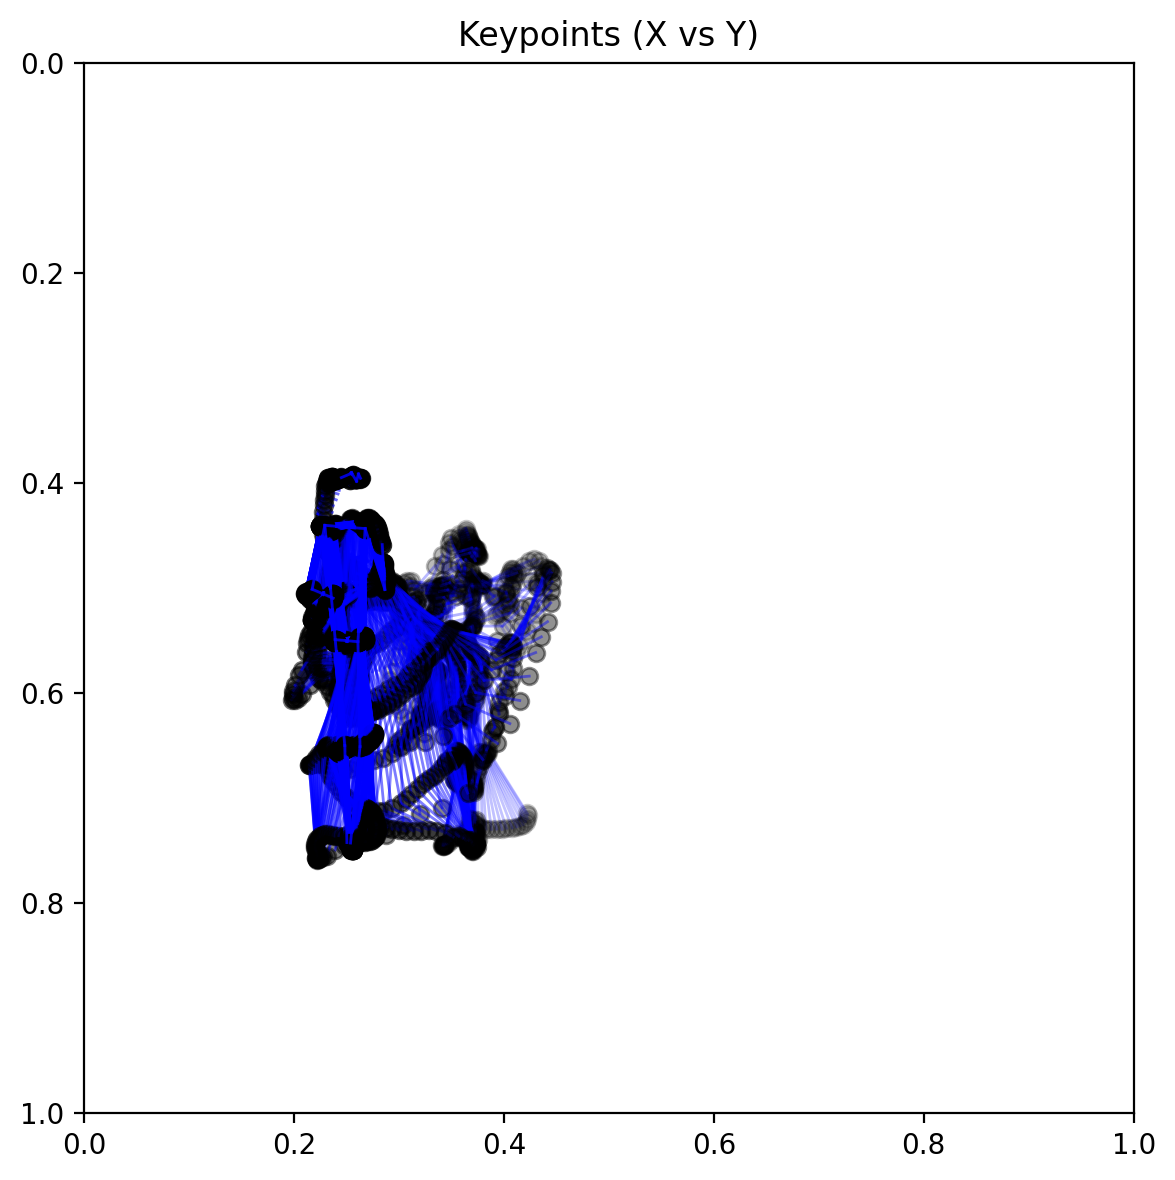

In [13]:
# XYZ coordinates subplot
fig, axs = plt.subplots(1, 1, figsize=(6, 6), facecolor='white', dpi=200)
alpha = 0.2
nodes = np.zeros([OUTPUT_LENGTH,17,2])
edges = np.zeros([OUTPUT_LENGTH,16,2,2])  # 12 edges, each with 2 points (start and end), each point has (x, y)

# XYZ coordinates for pos
for t in range(OUTPUT_LENGTH):
    alpha += 1.0 / 249  # Gradually decrease the transparency
    for i in range(17):
        kx, ky, kconf = groups_of_three(keypoints[t][5:])[i]  # Assuming the first 5 values are not keypoints
        nodes[t][i] = ([kx, ky])
        if kconf > 0.5:
            axs.plot(kx, ky, 'ko', alpha = alpha)  # Plot keypoints as red dots
    edges[t] = [(nodes[t][conn[0]], nodes[t][conn[1]]) for conn in coco_connections]
    for i in range(16):
        plot_line(axs, edges[t][i][0], edges[t][i][1], color='blue', linewidth=1, alpha=alpha)  # Plot edges as blue lines

axs.invert_yaxis()            # Flips the Y-axis so the head is at the top
axs.set_xlim(0, 1)            # Locks X-axis to normalized image bounds
axs.set_ylim(1, 0)            # Locks Y-axis to normalized bounds (1 at bottom, 0 at top)
axs.set_aspect('equal')       # Prevents the skeleton from stretching horizontally/vertically
axs.set_title('Keypoints (X vs Y)')
plt.tight_layout()
plt.show()

In [14]:
from ipywidgets import interact, IntSlider

def plot_pose_at_timestep(timestep):
    fig, axs = plt.subplots(1, 1, figsize=(3, 3), facecolor='white', dpi=200)
    alpha = 1.0
    nodes = np.zeros([17,2])
    for i in range(17):
        kx, ky, kconf = groups_of_three(keypoints[timestep][5:])[i]
        nodes[i] = ([kx, ky])
        if kconf > 0.5:
            axs.plot(kx, ky, 'ko', alpha=alpha)
    for conn in coco_connections:
        plot_line(axs, nodes[conn[0]], nodes[conn[1]], color='blue', linewidth=1, alpha=alpha)
    
    axs.invert_yaxis()            # Flips the Y-axis so the head is at the top
    axs.set_xlim(0, 1)            # Locks X-axis to normalized image bounds
    axs.set_ylim(1, 0)            # Locks Y-axis to normalized bounds (1 at bottom, 0 at top)
    axs.set_aspect('equal')       # Prevents the skeleton from stretching horizontally/vertically
    
    axs.set_title(f'Keypoints (X vs Y) - Timestep {timestep}')
    plt.tight_layout()
    plt.show()

interact(plot_pose_at_timestep, timestep=IntSlider(min=0, max=keypoints.shape[0]-1, step=1, value=0))

interactive(children=(IntSlider(value=0, description='timestep', max=152), Output()), _dom_classes=('widget-in…

<function __main__.plot_pose_at_timestep(timestep)>

In [15]:
from ipywidgets import Play, IntSlider, jslink, VBox

def plot_pose_at_timestep(timestep):
    fig, axs = plt.subplots(1, 1, figsize=(3, 3), facecolor='white', dpi=200)
    alpha = 1.0
    nodes = np.zeros([17,2])
    for i in range(17):
        kx, ky, kconf = groups_of_three(keypoints[timestep][5:])[i]
        nodes[i] = ([kx, ky])
        if kconf > 0.5:
            axs.plot(kx, ky, 'ro', alpha=alpha, markersize=2)
    for conn in coco_connections:
        plot_line(axs, nodes[conn[0]], nodes[conn[1]], color='blue', linewidth=1, alpha=alpha)
    axs.invert_yaxis()            # Flips the Y-axis so the head is at the top
    axs.set_xlim(0, 1)            # Locks X-axis to normalized image bounds
    axs.set_ylim(1, 0)            # Locks Y-axis to normalized bounds (1 at bottom, 0 at top)
    axs.set_aspect('equal')       # Prevents the skeleton from stretching horizontally/vertically
    axs.set_title(f'Keypoints (X vs Y) - Timestep {timestep}')
    plt.tight_layout()
    plt.show()

play = Play(value=0, min=0, max=keypoints.shape[0]-1, step=1, interval=50, description="Press play", repeat=True)
slider = IntSlider(min=0, max=keypoints.shape[0]-1, step=1, value=0)
jslink((play, 'value'), (slider, 'value'))

from ipywidgets import interactive_output
out = interactive_output(plot_pose_at_timestep, {'timestep': slider})

VBox([play, slider, out])

In [20]:
import ipywidgets as widgets
from ipywidgets import Play, IntSlider, jslink
from ipywidgets.embed import embed_minimal_html
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
from pathlib import Path

# Target export speed.
EXPORT_FPS = 59
ANIM_INTERVAL_MS = 1000 / EXPORT_FPS
WIDGET_INTERVAL_MS = max(1, int(round(ANIM_INTERVAL_MS)))

def plot_pose_at_timestep(timestep):
    fig, axs = plt.subplots(1, 1, figsize=(3, 3), facecolor='white', dpi=200)
    alpha = 1.0
    nodes = np.zeros([17, 2])
    for i in range(17):
        kx, ky, kconf = groups_of_three(keypoints[timestep][5:])[i]
        nodes[i] = [kx, ky]
        if kconf > 0.5:
            axs.plot(kx, ky, 'ro', alpha=alpha, markersize=2)
    for conn in coco_connections:
        plot_line(axs, nodes[conn[0]], nodes[conn[1]], color='blue', linewidth=1, alpha=alpha)
    axs.invert_yaxis()            # Flips the Y-axis so the head is at the top
    axs.set_xlim(0, 1)            # Locks X-axis to normalized image bounds
    axs.set_ylim(1, 0)            # Locks Y-axis to normalized bounds (1 at bottom, 0 at top)
    axs.set_aspect('equal')       # Prevents the skeleton from stretching horizontally/vertically
    axs.set_title(f'Keypoints (X vs Y) - Timestep {timestep}')
    plt.tight_layout()
    plt.show()

play = Play(value=0, min=0, max=keypoints.shape[0]-1, step=1, interval=WIDGET_INTERVAL_MS, description="Press play", repeat=True)
slider = IntSlider(min=0, max=keypoints.shape[0]-1, step=1, value=0)
jslink((play, 'value'), (slider, 'value'))

from ipywidgets import interactive_output
out = interactive_output(plot_pose_at_timestep, {'timestep': slider})

container = widgets.VBox([play, slider, out])
container

# Save the interactive widget as HTML (widgets cannot be written directly to mp4 bytes).
export_dir = Path('exports')
export_dir.mkdir(exist_ok=True)
widget_html_path = export_dir / 'pose_player_widget.html'
embed_minimal_html(str(widget_html_path), views=[container], title='Pose Player')
print(f'Saved interactive widget to: {widget_html_path.resolve()}')

# Save a real animation file from the same keypoint data.
fig, ax = plt.subplots(1, 1, figsize=(3, 3), facecolor='white', dpi=200)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_ylim(1, 0)
ax.set_aspect('equal')

scatter = ax.scatter([], [], c='red', s=8)
lines = [ax.plot([], [], color='blue', linewidth=1)[0] for _ in coco_connections]

def init_anim():
    scatter.set_offsets(np.empty((0, 2)))
    for line in lines:
        line.set_data([], [])
    return [scatter, *lines]

def update_anim(timestep):
    nodes = np.zeros((17, 2))
    valid_points = []
    for i in range(17):
        kx, ky, kconf = groups_of_three(keypoints[timestep][5:])[i]
        nodes[i] = [kx, ky]
        if kconf > 0.5:
            valid_points.append([kx, ky])

    if valid_points:
        scatter.set_offsets(np.array(valid_points))
    else:
        scatter.set_offsets(np.empty((0, 2)))

    for line, conn in zip(lines, coco_connections):
        p1 = nodes[conn[0]]
        p2 = nodes[conn[1]]
        line.set_data([p1[0], p2[0]], [p1[1], p2[1]])

    ax.set_title(f'Keypoints (X vs Y) - Timestep {timestep}')
    return [scatter, *lines]

ani = FuncAnimation(
    fig,
    update_anim,
    frames=keypoints.shape[0],
    init_func=init_anim,
    interval=ANIM_INTERVAL_MS,
    blit=True
 )

mp4_path = export_dir / 'pose_animation.mp4'
gif_path = export_dir / 'pose_animation.gif'

try:
    writer = FFMpegWriter(fps=EXPORT_FPS, bitrate=1800)
    ani.save(str(mp4_path), writer=writer)
    print(f'Saved animation to: {mp4_path.resolve()} @ {EXPORT_FPS} FPS')
except Exception as err:
    print(f'FFmpeg not available ({err}). Saving GIF fallback instead.')
    ani.save(str(gif_path), writer=PillowWriter(fps=EXPORT_FPS))
    print(f'Saved animation to: {gif_path.resolve()} @ {EXPORT_FPS} FPS')

plt.close(fig)

Saved interactive widget to: D:\GitHub\BaseballPitch\modules\motion_prediction\exports\pose_player_widget.html
Saved animation to: D:\GitHub\BaseballPitch\modules\motion_prediction\exports\pose_animation.mp4 @ 59 FPS
